In [1]:
# import dependencies
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, Normalize
import os

TO-DO:

[PHOTO: Aerial or street-level view of Bennington, with the Walloomsac River visible]
- Generate an article-ready caption and alt text for this image: file path

[PHOTO: Aerial damage from Hurricane Irene, 2011 — Vermont road washout or bridge collapse]
- Find public-domain FEMA or Vermont 2011 Irene damage photos for Vermont road/bridge washout; return 2–3 candidate images with source URLs and suggested captions

[PHOTO: 2023 flooding in Montpelier or Barre — downtown street with water]
- Find public images of July 2023 Montpelier/Barre flooding suitable for publication (FEMA/state/press with usage terms).

[GRAPHIC: "52%" — large stat callout or donut chart showing share of Vermont towns with zero HMA funding]
- Generate an SVG donut stat "52% of VT towns received $0 HMA funding" using palette YOUR_PALETTE

[GRAPHIC: Index schematic — "Need = Risk (EAL) + Vulnerability (poverty rate, elderly share, no-vehicle households)"]  
- Create an SVG schematic: 'Need = Risk (EAL) + Vulnerability (poverty, elderly, no-vehicle)', horizontal boxes, arrows, simple icons, match palette YOUR_PALETTE, output figs/index_schematic.svg.

[GRAPHIC: Choropleth map — need index by Vermont town, diverging palette, high-need towns labeled including Bennington and Newport]
- Clip from dashboard

[GRAPHIC: Choropleth map — HMA funding received by Vermont town, same projection and scale as above]
- Clip from dashboard

[GRAPHIC: Scatter plot — need rank (x-axis) vs. funding rank (y-axis), quadrant lines, annotated outliers including Bennington and Newport labeled as notable zero-funding cases]
- Adapt JS version

[GRAPHIC: Quadrant chart — need rank vs. funding rank scatter with quadrant overlays; Bennington and Newport labeled; other notable high-need, zero-funding towns visible]
- Clip from dashboard

[CONSIDER: quote from Newport city official, local emergency manager, or Vermont state hazard mitigation officer here] 
- Find a recent quote about flood mitigation capacity or grant application burdens from Newport/Bennington officials; return quote, source, and link

[VERIFY: ERAF eligibility criteria and connection to FIRM designations]
- Confirm how revised FIRM/FEMA maps interact with Vermont ERAF eligibility and cite Vermont DEC/VEM guidance

[VERIFY: exact details of BRIC elimination, date, and whether it was a full elimination or funding rescission]
- Confirm BRIC program status (2025) and provide authoritative citation (Congressional Research Service / FEMA / DOI).

[VERIFY: specific examples of state-level programs, and Vermont's post-2023 state-level efforts if any exist]
- List Vermont state mitigation funds/programs and post-2023 policy actions (VT ANR, VEM) with links.

[PHOTO: Bennington streetscape or the Walloomsac River at current water level]
- Generate an article-ready caption and alt text for this image: file path

In [2]:
# color palettes
quadrant_colors = {
  "zero_funding": "#888888", # gray for absent/unknown feels right
  "underfunded": "#d55e00", # vermilion — warm alarm, not pure red, CVD-distinguishable
  "aligned": "#0072b2", # deep blue — matches dashboard primary theme (#0085a1)
  "overfunded": "#cc79a7", # mauve/pink — distinct from vermilion under CVD
  "low_priority": "#e69f00", # amber — warm but lower urgency than vermilion
}

In [3]:
# open geojson file
gdf = gpd.read_file("../docs/static/resources/town_boundaries.geojson")

# open town stats file
df = pd.read_csv("../docs/static/resources/town_stats.csv")

# open hma data
df_hma = pd.read_csv("../data/cleaned/fema_hma_projects_clean.csv")

In [4]:
# remove "State of Vermont" from df
df = df[df.town_name != "State of Vermont"].copy()

In [5]:
# # merge stats onto geometry, using GEOID as the key
# df['GEOID']  = df['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
# gdf['GEOID'] = gdf['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# # check for mismatches in the key before merging
# # df_keys = set(df['GEOID'])
# # gdf_keys = set(gdf['GEOID'])
# # missing_in_gdf = df_keys - gdf_keys
# # if missing_in_gdf:
# #     print(f"Warning: {len(missing_in_gdf)} GEOIDs in df not found in gdf. Sample: {list(missing_in_gdf)[:5]}")
# # perform the merge
# gdf_merged = gdf.merge(df, on=['GEOID', 'town_name'], how='left', suffixes=('', '_stats'))
# gdf_merged.columns

In [6]:
# get Newport City pct_below_poverty
print(f"Newport city poverty rate: {df[df.town_name == 'Newport city'].pct_below_poverty.values[0]:.2f}%")

Newport city poverty rate: 23.00%


In [7]:
## get total FEMA HMA funding, all time, nationally
# 
#  open all fema hma projects
all_hma = pd.read_csv("../data/raw/funding/HazardMitigationAssistanceProjects.csv")
all_hma.columns

# open CPI csv and calculate annual average CPI values for each year
cpi = pd.read_csv("../data/resources/CPIAUCSL.csv")
cpi["DATE"] = pd.to_datetime(cpi["observation_date"])
cpi["year"] = cpi["DATE"].dt.year
cpi_annual = cpi.groupby("year")["CPIAUCSL"].mean().reset_index()
# display(cpi_annual.tail())

# get most recent full year
reference_year = cpi_annual["year"].max()
if pd.Timestamp.now().year == reference_year:
    reference_year -= 1
cpi_ref = cpi_annual.loc[cpi_annual["year"] == reference_year, "CPIAUCSL"].values[0]
# print(f"Reference year: {reference_year}, CPI: {cpi_ref:.4f}")

# create a CPI lookup dictionary
cpi_lookup = dict(zip(cpi_annual["year"], cpi_annual["CPIAUCSL"]))
# calculate adjustment factors for each year in the dataset
# adjustment factor = CPI in reference year / CPI in project year
cpi_factors = {year: cpi_ref / cpi_value for year, cpi_value in cpi_lookup.items()}
# print("CPI adjustment factors:")
# for year, factor in cpi_factors.items():
#     print(f"{year}: {factor:.4f}")

# apply adjustment to each row
all_hma["federalShareObligated_adj"] = all_hma.apply(
    # inflation adjusted amount = nominal amount * (CPI in reference year / CPI in project year)
    lambda row: row["federalShareObligated"] * cpi_factors.get(row["programFy"], 1.0),
    axis=1,
)

# sum adjusted funding
print("Total FEMA HMA spending (all projects):")
print(f"Funding in {reference_year} dollars:")
print(f"Total nominal funding: ${all_hma['federalShareObligated'].sum():,.2f}")
print(f"Total inflation-adjusted funding: ${all_hma['federalShareObligated_adj'].sum():,.2f}")

Total FEMA HMA spending (all projects):
Funding in 2025 dollars:
Total nominal funding: $21,118,862,807.21
Total inflation-adjusted funding: $31,665,956,768.18


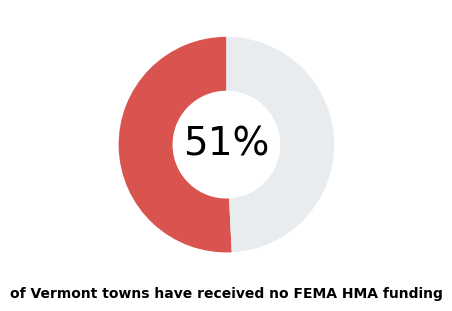

In [8]:
# 52% donut for towns with zero funding
zero=(df['funding_total']==0).sum()
total=len(df)
pct=zero/total
fig,ax=plt.subplots(figsize=(3.5,3.5))
ax.pie([pct,1-pct], colors=['#d9534f','#e9ecef'], startangle=90, wedgeprops=dict(width=0.5))
ax.text(0,0,f'{pct*100:.0f}%', ha='center', va='center', fontsize=28)
ax.set_title('of Vermont towns have received no FEMA HMA funding', fontsize=10, fontweight='bold', y=-0.1)
# plt.savefig('figs/52pct_donut.svg', bbox_inches='tight')
plt.show()

The above donut sucks. And I like the round 52% that you get if you exclude the six zero-population towns (a 130:120 ratio of nonfunded:funded towns)

In [9]:
130/250

0.52

In [10]:
# out_dir = "../docs/static/images"
# os.makedirs(out_dir, exist_ok=True)

# def _norm(vals, fixed_domain=None, center=0.0):
#     a = np.asarray(vals)
#     a = a[~np.isnan(a)]
#     if a.size == 0:
#         return None
#     if fixed_domain is not None:
#         return TwoSlopeNorm(vmin=fixed_domain[0], vcenter=center, vmax=fixed_domain[1])
#     vmin, vmax = a.min(), a.max()
#     return TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax) if (vmin < center < vmax) else Normalize(vmin=vmin, vmax=vmax)

# def plot_choropleth(gdf, col, title, outpath,
#                     cmap="RdYlBu_r", annotate=("Bennington","Newport city"),
#                     figsize=(10,10), fixed_domain=None, save=True):
#     norm = _norm(gdf[col].dropna().values, fixed_domain=fixed_domain)
#     if norm is None:
#         raise ValueError(f"No numeric values present for {col}")

#     fig, ax = plt.subplots(figsize=figsize, dpi=200)
#     gdf.plot(column=col, cmap=cmap, norm=norm, linewidth=0.2, edgecolor="white",
#              ax=ax, missing_kwds={"color":"#f0f0f0"})

#     xmin, xmax = ax.get_xlim(); ymin, ymax = ax.get_ylim()
#     xoff = (xmax - xmin) * 0.015; yoff = (ymax - ymin) * 0.015
#     for name in annotate:
#         s = gdf[gdf["town_name"].str.contains(name, case=False, na=False)]
#         if s.empty:
#             print(f"Warning: '{name}' not found")
#             continue
#         geom = s.geometry.unary_union.centroid
#         ax.scatter([geom.x], [geom.y], s=25, color="black", zorder=6)
#         ax.text(geom.x + xoff, geom.y + yoff, name, fontsize=10, fontweight="bold",
#                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8), zorder=7)

#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm._A = []
#     cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
#     cbar.ax.tick_params(labelsize=9); cbar.set_label(title, fontsize=10)
#     ax.set_title(title, fontsize=14, weight="bold"); ax.axis("off"); plt.tight_layout()

#     if save:
#         # fig.savefig(outpath, format="svg", bbox_inches="tight")
#         # print("Saved:", outpath)
#     plt.show(); plt.close(fig)

# # Example calls that match D3's [-1, 0, 1] diverging domain:
# plot_choropleth(gdf_merged, "need_eal_rel", "Combined Need (EAL) — vs VT average",
#                 os.path.join(out_dir, "need_choropleth.svg"), fixed_domain=(-1,1), figsize=(12,10))

# plot_choropleth(gdf_merged, "funding_rel", "Relative Mitigation Funding (vs VT average)",
#                 os.path.join(out_dir, "funding_choropleth.svg"), fixed_domain=(-1,1), figsize=(12,10))

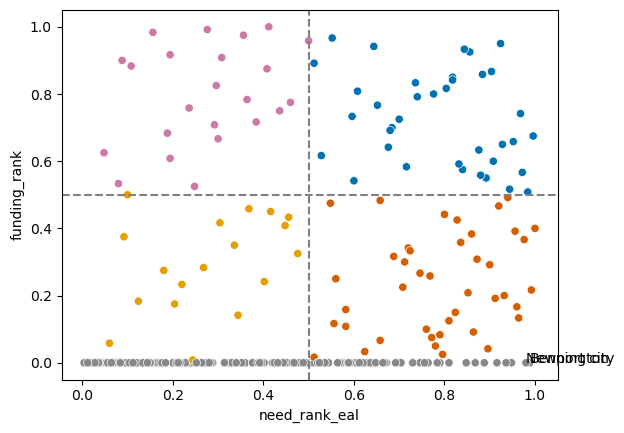

In [11]:
# TODO fix annotations, maybe use js version
sns.scatterplot(data=df, x='need_rank_eal', y='funding_rank', hue='quadrant_eal', palette=quadrant_colors, legend=False)
plt.axvline(0.5, color='grey', linestyle='--'); plt.axhline(0.5, color='grey', linestyle='--')
for t in ['Bennington','Newport city']:
    r=df[df['town_name'].str.contains(t, case=False)].iloc[0]
    plt.text(r['need_rank_eal'], r['funding_rank'], t)
# plt.savefig('../docs/static/images/need_vs_funding_scatter.svg', bbox_inches='tight')
plt.show()

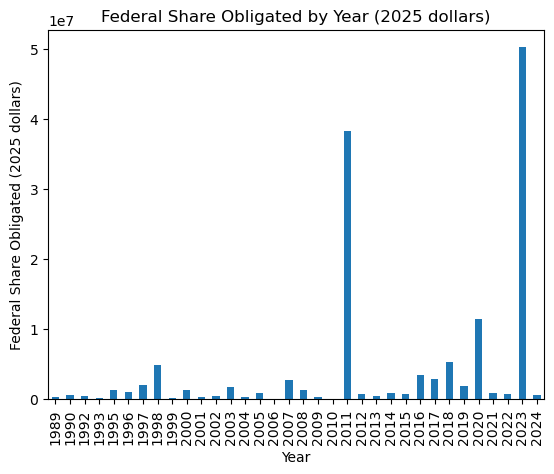

In [12]:
# TODO annotate 2011 and 2023, format

# plot FEMA HMA amount obligated by year
df_hma.groupby('programFy')['federalShareObligated_adj'].sum().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Federal Share Obligated (2025 dollars)')
plt.title('Federal Share Obligated by Year (2025 dollars)')
plt.savefig('../docs/static/images/funding_by_year.svg', bbox_inches='tight')
plt.show()

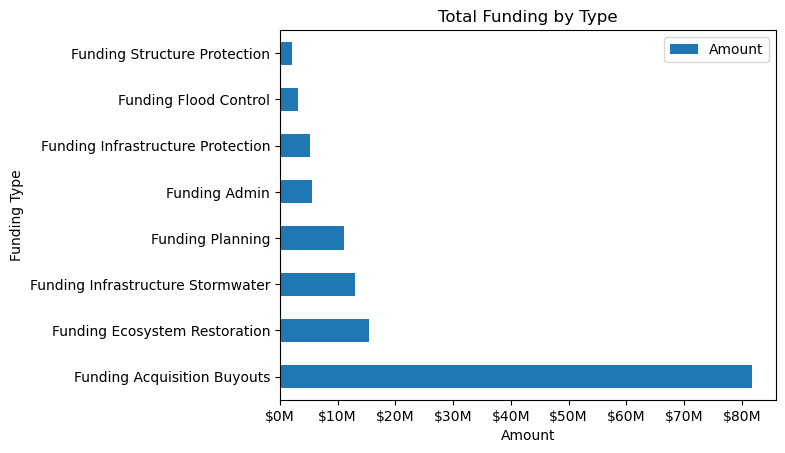

In [13]:
# drop other and equipment
funding_cols = [col for col in df_hma.columns if col.startswith('funding_') and col not in ['funding_other', 'funding_equipment']]  
# plot all "funding_*" columns, grouped
funding_df = df_hma[funding_cols].sum().reset_index()
funding_df.columns = ['Funding Type', 'Amount']
funding_df = funding_df.sort_values(by='Amount', ascending=False)
funding_df['Funding Type'] = funding_df['Funding Type'].str.replace('_', ' ').str.title()
funding_df.plot(kind='barh', x='Funding Type', y='Amount')
plt.xlabel('Amount')
plt.ylabel('Funding Type')
# xaxis ticks in million dollar amounts
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.title('Total Funding by Type')
plt.savefig('../docs/static/images/funding_by_type.svg', bbox_inches='tight')
plt.show()

In [14]:
# # ensure quadrant order matches your palette
# quadrant_order = list(quadrant_colors.keys())
# gdf_merged["quadrant_eal"] = pd.Categorical(
#     gdf_merged["quadrant_eal"], categories=quadrant_order, ordered=True
# )

# # filter out rows without quadrant or geometry and map colors (preserves row order)
# gdf_plot = gdf_merged[gdf_merged["quadrant_eal"].notna() & gdf_merged.geometry.notna()].copy()
# colors = gdf_plot["quadrant_eal"].map(quadrant_colors).tolist()

# # create figure/axis
# fig, ax = plt.subplots(figsize=(10, 8))
# gdf_plot.plot(color=colors, edgecolor="black", linewidth=0.2, ax=ax)

# # ordered legend matching quadrant_order
# handles = [mpatches.Patch(color=quadrant_colors[k], label=k) for k in quadrant_order]
# ax.legend(handles=handles, title="Quadrant", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

# # annotate Bennington and Newport (substring match)
# for name in ["Bennington", "Newport city"]:
#     subset = gdf_plot[gdf_plot["town_name"].str.contains(name, case=False, na=False)]
#     if subset.empty:
#         print(f"Warning: town matching '{name}' not found")
#         continue
#     cent = subset.geometry.unary_union.centroid
#     ax.scatter(cent.x, cent.y, s=60, color="black", zorder=6)
#     xoff = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01
#     yoff = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01
#     ax.text(
#         cent.x + xoff,
#         cent.y + yoff,
#         name,
#         fontsize=10,
#         fontweight="bold",
#         bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
#         zorder=7,
#     )

# ax.set_title("Geographic Distribution of Funding Alignment")
# ax.axis("off")
# ax.set_aspect("equal")
# # plt.savefig("../docs/static/images/quadrant_chart.svg", format="svg", bbox_inches="tight")
# plt.show()

C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\2138471292.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_by_q = df.dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\2138471292.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zero_by_q = df[df['funding_total'] == 0].dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\2138471292.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplo

Saved


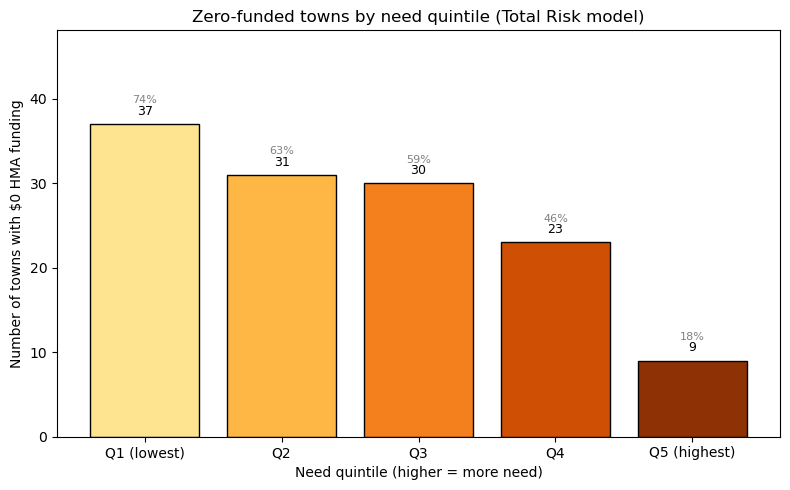

In [15]:
# Create bar chart of count of zero‑funding towns by need quintile (compute quintiles from need_rank_eal)

# !!!! EAL model!!!!!!!

# compute quintiles from need_rank_eal (0-1)
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
df['need_quintile'] = pd.cut(df['need_rank_eal'], bins=bins, labels=labels, include_lowest=True, right=True)

# counts
total_by_q = df.dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
zero_by_q = df[df['funding_total'] == 0].dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.get_cmap('YlOrBr')
colors = cmap(np.linspace(0.25, 0.9, len(labels)))
bars = ax.bar(labels, zero_by_q.values, color=colors, edgecolor='k')

# annotate counts and percent of quintile that are zero-funded
pct = (zero_by_q / total_by_q.replace(0, np.nan) * 100).fillna(0)
for bar, count, p in zip(bars, zero_by_q.values, pct.values):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(0.4, 0.02 * max(zero_by_q.max(), 1)),
            f'{int(count)}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(1.2, 0.06 * max(zero_by_q.max(), 1)),
            f'{p:.0f}%', ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xlabel('Need quintile (higher = more need)')
ax.set_ylabel('Number of towns with $0 HMA funding')
ax.set_title('Zero-funded towns by need quintile (Total Risk model)')
ax.set_ylim(0, max(zero_by_q.max() * 1.3, 5))
plt.tight_layout()

fig.savefig('../docs/static/images/zero_funding_by_quintile.svg', format='svg', bbox_inches='tight')
print('Saved')
plt.show()

C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\686533346.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_by_q = df.dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\686533346.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zero_by_q = df[df['funding_total'] == 0].dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
C:\Users\johbr\AppData\Local\Temp\ipykernel_1944\686533346.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotli

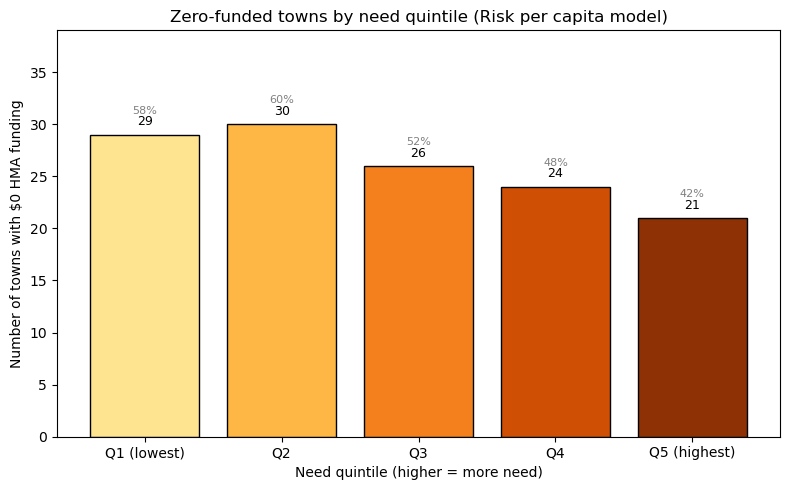

In [16]:
# Create bar chart of count of zero‑funding towns by need quintile (compute quintiles from need_rank_eal_per_capita)

# !!!! EAL per capita model!!!!!

# compute quintiles from need_rank_eal_per_capita (0-1)
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
df['need_quintile'] = pd.cut(df['need_rank_eal_per_capita'], bins=bins, labels=labels, include_lowest=True, right=True)

# counts
total_by_q = df.dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)
zero_by_q = df[df['funding_total'] == 0].dropna(subset=['need_quintile']).groupby('need_quintile').size().reindex(labels, fill_value=0)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.get_cmap('YlOrBr')
colors = cmap(np.linspace(0.25, 0.9, len(labels)))
bars = ax.bar(labels, zero_by_q.values, color=colors, edgecolor='k')

# annotate counts and percent of quintile that are zero-funded
pct = (zero_by_q / total_by_q.replace(0, np.nan) * 100).fillna(0)
for bar, count, p in zip(bars, zero_by_q.values, pct.values):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(0.4, 0.02 * max(zero_by_q.max(), 1)),
            f'{int(count)}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(1.2, 0.06 * max(zero_by_q.max(), 1)),
            f'{p:.0f}%', ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xlabel('Need quintile (higher = more need)')
ax.set_ylabel('Number of towns with $0 HMA funding')
ax.set_title('Zero-funded towns by need quintile (Risk per capita model)')
ax.set_ylim(0, max(zero_by_q.max() * 1.3, 5))
plt.tight_layout()

# fig.savefig('../docs/static/images/zero_funding_by_quintile.svg', format='svg', bbox_inches='tight')
# print('Saved')
plt.show()